# 07 - Exploration des Données Images

## Section : Gestion des Images

### Classification de Produits E-commerce

## Objectif
Explorer le jeu d'images produits pour :
- La **structure** du dataset (chemins, formats, convention de nommage)
- La **couverture** (produits avec/sans image)
- La **distribution** des classes par image
- Les **caractéristiques** visuelles (tailles, formats, qualité)
- La **détection** d'images potentiellement corrompues

## Plan
1. Chargement et inventaire des images
2. Analyse de la couverture produit / image
3. Distribution des classes
4. Caractéristiques des images (tailles, formats)
5. Échantillons visuels par classe
6. Détection d'anomalies (fichiers corrompus)
7. Synthèse et recommandations

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('../').resolve()))

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

ROOT = Path('../').resolve()
DATA_BRUT = ROOT / 'data brut'

IMAGE_DIR_RAW_TRAIN = DATA_BRUT / 'image_train'
IMAGE_DIR_RAW_BRUT = DATA_BRUT / 'image_brut'
IMAGE_DIR_PROCESSED_TRAIN = ROOT / 'data' / 'processed' / 'image_clean'
IMAGE_DIR_PROCESSED_CLEAN = ROOT / 'data' / 'processed' / 'image_clean'

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_image_files(image_dir: Path):
    if not image_dir.exists():
        return []
    return [p for p in image_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

# Choix automatique du dossier d'images (train/brut, tous formats courants)
candidates = [
    IMAGE_DIR_RAW_TRAIN,
    IMAGE_DIR_RAW_BRUT,
    IMAGE_DIR_PROCESSED_TRAIN,
    IMAGE_DIR_PROCESSED_CLEAN,
]

IMAGE_DIR = None
for candidate in candidates:
    if list_image_files(candidate):
        IMAGE_DIR = candidate
        break

if IMAGE_DIR is None:
    IMAGE_DIR = IMAGE_DIR_RAW_BRUT

print("✅ Bibliothèques importées")
print(f"📁 Images : {IMAGE_DIR}")
if not list_image_files(IMAGE_DIR):
    print("⚠️ Aucun fichier image trouvé (.jpg/.jpeg/.png/.bmp/.webp). Vérifie le dossier image_brut/image_train.")

✅ Bibliothèques importées
📁 Images : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data brut\image_brut


## 1. Inventaire des Images

In [9]:
if any(name not in globals() for name in ['IMAGE_DIR', 'IMAGE_EXTS', 'list_image_files']):
    raise RuntimeError("Exécute d'abord la cellule d'initialisation (imports/chemins).")

image_files = list_image_files(IMAGE_DIR)
print(f"📷 Nombre total de fichiers image : {len(image_files):,}")
print(f"   Formats pris en charge : {', '.join(sorted(IMAGE_EXTS))}")
print("   Convention : image_{imageid}_product_{productid}.[ext]")

image_data = []
for f in image_files:
    try:
        parts = f.stem.split('_')
        if len(parts) >= 4 and parts[0].lower() == 'image' and parts[2].lower() == 'product':
            image_data.append({'imageid': int(parts[1]), 'productid': int(parts[3]), 'path': str(f)})
    except (ValueError, IndexError):
        pass

image_df = pd.DataFrame(image_data)
print(f"\n✅ Images parsées : {len(image_df):,}")
print(f"   Produits uniques : {image_df['productid'].nunique():,}")
image_df.head(10)

📷 Nombre total de fichiers image : 46,860
   Formats pris en charge : .bmp, .jpeg, .jpg, .png, .webp
   Convention : image_{imageid}_product_{productid}.[ext]

✅ Images parsées : 46,860
   Produits uniques : 46,860


,imageid,productid,path
0,1142089742,884747735,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
1,1250268190,3831364140,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
2,1250268206,3831364148,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
3,1250268214,3831364212,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
4,1250268262,3831364233,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
5,1250268322,3831364246,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
6,1250268338,3831364249,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
7,1250278217,3831652226,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
8,1250279240,3831652823,C:\Users\pruvost_t\Desktop\Cours\Datascientest...
9,1250327863,3266536534,C:\Users\pruvost_t\Desktop\Cours\Datascientest...


## 2. Couverture Produit / Image

In [10]:
X_train = pd.read_csv(DATA_BRUT / 'X_train_update.csv', index_col=0)
y_train = pd.read_csv(DATA_BRUT / 'Y_train.csv', index_col=0)

merged_cov = X_train.merge(image_df[['productid', 'imageid']], on=['productid', 'imageid'], how='inner')
covered = len(merged_cov)
total = len(X_train)

print(f"📊 Couverture :")
print(f"   Produits totaux (train) : {total:,}")
print(f"   Produits avec image : {covered:,} ({100*covered/total:.1f}%)")
print(f"   Produits sans image : {total - covered:,}")

📊 Couverture :
   Produits totaux (train) : 84,916
   Produits avec image : 46,860 (55.2%)
   Produits sans image : 38,056


## 3. Distribution des Classes

📊 Distribution par classe (27 classes) :
prdtypecode
10      1661
40      1385
50       947
60       449
1140    1483
1160    2109
1180     423
1280    2650
1281    1126
1300    2788
1301     423
1302    1385
1320    1871
1560    2866
1920    2430
1940     407
2060    2798
2220     459
2280    2681
2403    2607
2462     794
2522    2719
2582    1398
2583    5591
2585    1398
2705    1528
2905     484
Name: count, dtype: int64


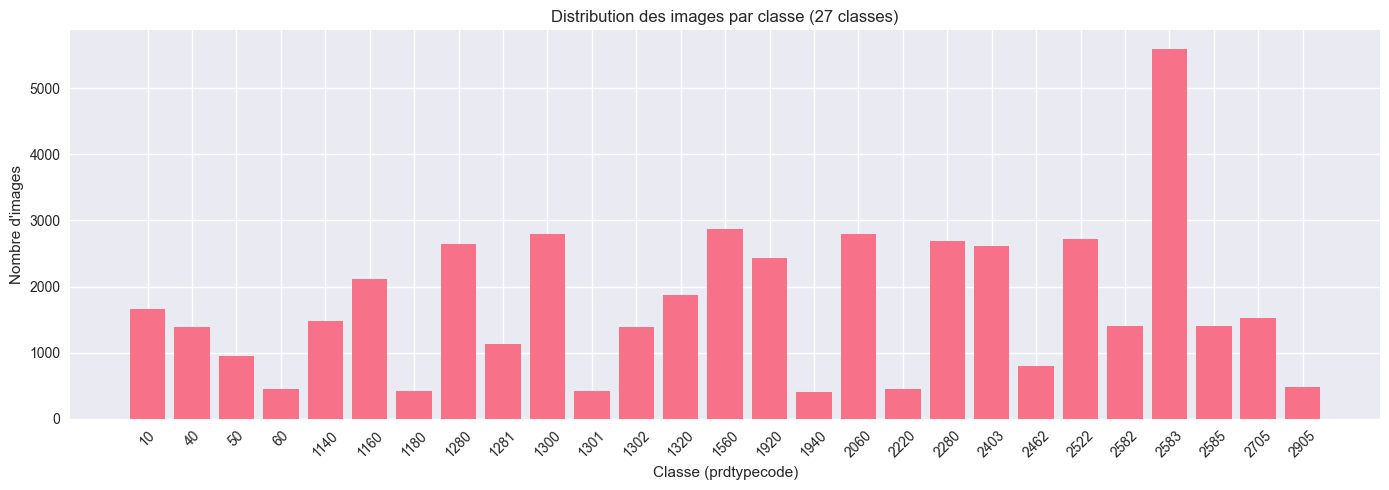

In [11]:
merged = X_train.merge(image_df[['productid', 'imageid']], on=['productid', 'imageid'], how='inner')
merged = merged.merge(y_train, left_index=True, right_index=True)

class_dist = merged['prdtypecode'].value_counts().sort_index()

print(f"📊 Distribution par classe (27 classes) :")
print(class_dist)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(class_dist)), class_dist.values)
ax.set_xlabel('Classe (prdtypecode)')
ax.set_ylabel('Nombre d\'images')
ax.set_title('Distribution des images par classe (27 classes)')
plt.xticks(range(len(class_dist)), class_dist.index, rotation=45)
plt.tight_layout()
plt.show()

## 4. Caractéristiques des Images (tailles, formats)

In [12]:
from PIL import Image

sample_size = min(500, len(image_df))
sample = image_df.sample(n=sample_size, random_state=42)

sizes = []
for _, row in sample.iterrows():
    try:
        with Image.open(row['path']) as img:
            sizes.append({'w': img.width, 'h': img.height})
    except Exception:
        sizes.append({'w': None, 'h': None})

sizes_df = pd.DataFrame(sizes)
valid = sizes_df.dropna()
print(f"📐 Échantillon de {len(valid)} images :")
print(f"   Largeur : min={valid['w'].min()}, max={valid['w'].max()}, médiane={valid['w'].median():.0f}")
print(f"   Hauteur : min={valid['h'].min()}, max={valid['h'].max()}, médiane={valid['h'].median():.0f}")
print(f"   Corrompues / illisibles : {len(sizes_df) - len(valid)}")

📐 Échantillon de 500 images :
   Largeur : min=500, max=500, médiane=500
   Hauteur : min=500, max=500, médiane=500
   Corrompues / illisibles : 0


## 5. Échantillons Visuels par Classe

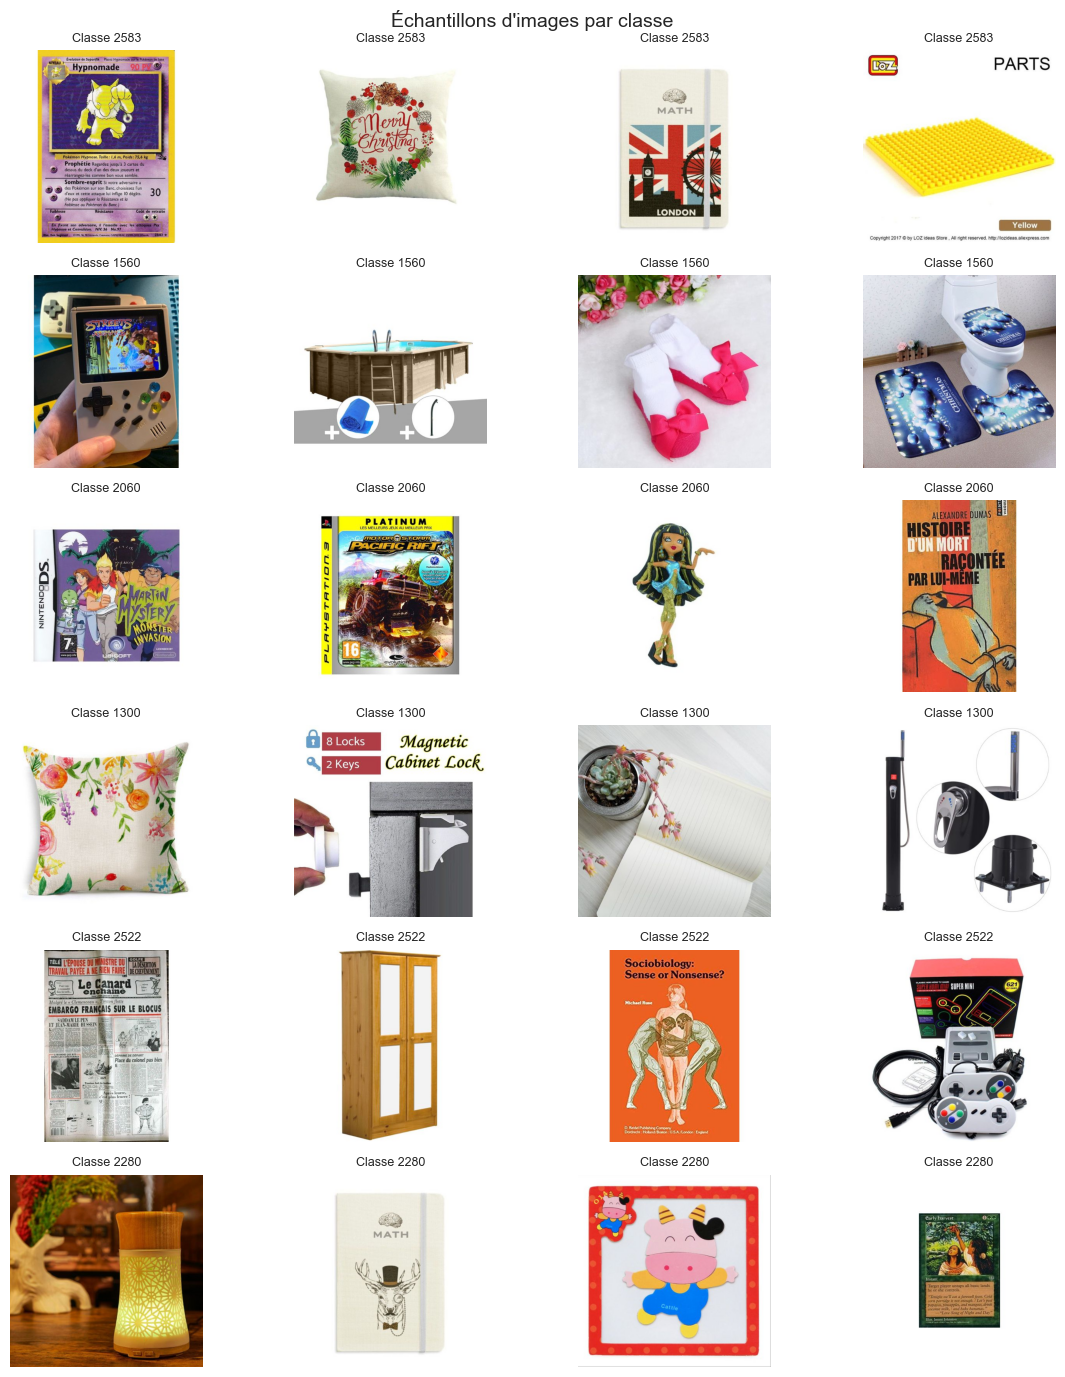

In [13]:
df_with_class = merged.merge(image_df[['productid', 'imageid', 'path']], on=['productid', 'imageid'])

n_classes_show = 6
samples_per_class = 4
classes = df_with_class['prdtypecode'].value_counts().head(n_classes_show).index.tolist()

fig, axes = plt.subplots(n_classes_show, samples_per_class, figsize=(12, 14))
for i, cls in enumerate(classes):
    sub = df_with_class[df_with_class['prdtypecode'] == cls].sample(n=samples_per_class, random_state=42)
    for j, (_, row) in enumerate(sub.iterrows()):
        try:
            img = Image.open(row['path']).convert('RGB')
            axes[i, j].imshow(img)
        except Exception:
            axes[i, j].text(0.5, 0.5, 'Erreur', ha='center', va='center')
        axes[i, j].set_title(f"Classe {cls}", fontsize=9)
        axes[i, j].axis('off')
plt.suptitle('Échantillons d\'images par classe', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Synthèse et Recommandations

In [14]:
print("📋 Synthèse de l'exploration :")
print(f"   • Images disponibles : {len(image_df):,}")
print(f"   • Couverture produits : {100*covered/total:.1f}%")
print(f"   • 27 classes représentées : {merged['prdtypecode'].nunique()}")
print(f"   • Format attendu : redimensionnement 224×224 pour ResNet")
print("\n✅ Prochaine étape : Notebook 08 - Traitement des images")

📋 Synthèse de l'exploration :
   • Images disponibles : 46,860
   • Couverture produits : 55.2%
   • 27 classes représentées : 27
   • Format attendu : redimensionnement 224×224 pour ResNet

✅ Prochaine étape : Notebook 08 - Traitement des images
